In [2]:
import sys
from langchain_openai import ChatOpenAI,OpenAIEmbeddings
from langchain_core.messages import HumanMessage,AIMessage,SystemMessage,BaseMessage
from langchain_core.output_parsers import StrOutputParser,PydanticOutputParser
from langchain_core.prompts import PromptTemplate,ChatPromptTemplate
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph.message import add_messages
from langgraph.checkpoint.sqlite import SqliteSaver
sys.path.insert(1, r'D:\Notebooks\LLM\env')
from enviorment import load_env
import os 
load_env()
model =ChatOpenAI()
from langgraph.graph import StateGraph,START, END
from typing import TypedDict,Annotated
import operator
import sqlite3


In [3]:
class bot(TypedDict):
    messages :Annotated[list[BaseMessage], add_messages]

In [4]:
conn = sqlite3.connect(database='chatbot.db', check_same_thread=False)
# Checkpointer
checkpoint = SqliteSaver(conn=conn)
#chatbot = graph.compile(checkpointer=checkpointer)

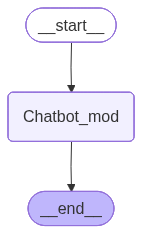

In [5]:

def Chatbot_mod(state:bot):
    text=state['messages']
    #print ('text datatype ',type(text))
    #print ('text is',text)
   
    result=model.invoke(text,config=config)
    #output=result['messages'][-1].content
    #messages =[AIMessage(result['messages'][-1].content)]
    #print ('messages ',messages)
    return {'messages' :[result]}
#checkpoint =InMemorySaver()

graph=StateGraph(bot)
graph.add_node('Chatbot_mod',Chatbot_mod)
graph.add_edge(START,'Chatbot_mod')
graph.add_edge('Chatbot_mod',END)
workflow =graph.compile(checkpointer=checkpoint)
workflow




In [6]:
config = {"configurable": {"thread_id": "2"}}

In [7]:
text ='you are cool'
config = {"configurable": {"thread_id": "2"}}
#initial_state={'messages' :[HumanMessage(content=text)]}
message ={'messages':[HumanMessage(content=text)]}
#print ('initial_state ',initial_state)
workflow.invoke(message,config=config)

{'messages': [HumanMessage(content='you are cool', additional_kwargs={}, response_metadata={}, id='4595f7c0-a9b5-43db-a666-dc3dacd24314', example=False),
  AIMessage(content="Thank you! I'm just here to help and provide information. Let me know if you have any questions or need assistance with anything.", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 10, 'total_tokens': 37, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-CT462ZaD7R075LhQZ8SMG2djzWiXc', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--77354869-5504-4405-b37b-a7ea6d0291df-0', usage_metadata={'input_tokens': 10, 'output_tokens': 27, 'total_tokens': 37, 'input_token_details': {'audio': 0, 'ca

In [8]:
text ='my name is dharmendra'

#initial_state={'messages' :[HumanMessage(content=text)]}
message ={'messages':[HumanMessage(content=text)]}
#print ('initial_state ',initial_state)
workflow.invoke(message,config=config)

{'messages': [HumanMessage(content='you are cool', additional_kwargs={}, response_metadata={}, id='4595f7c0-a9b5-43db-a666-dc3dacd24314', example=False),
  AIMessage(content="Thank you! I'm just here to help and provide information. Let me know if you have any questions or need assistance with anything.", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 10, 'total_tokens': 37, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-CT462ZaD7R075LhQZ8SMG2djzWiXc', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--77354869-5504-4405-b37b-a7ea6d0291df-0', usage_metadata={'input_tokens': 10, 'output_tokens': 27, 'total_tokens': 37, 'input_token_details': {'audio': 0, 'ca

In [11]:
text ='what is my name'

#initial_state={'messages' :[HumanMessage(content=text)]}
message ={'messages':[HumanMessage(content=text)]}
#print ('initial_state ',initial_state)
workflow.invoke(message,config=config)

{'messages': [HumanMessage(content='you are cool', additional_kwargs={}, response_metadata={}, id='4595f7c0-a9b5-43db-a666-dc3dacd24314'),
  AIMessage(content="Thank you! I'm just here to help and provide information. Let me know if you have any questions or need assistance with anything.", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 10, 'total_tokens': 37, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-CT462ZaD7R075LhQZ8SMG2djzWiXc', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--77354869-5504-4405-b37b-a7ea6d0291df-0', usage_metadata={'input_tokens': 10, 'output_tokens': 27, 'total_tokens': 37, 'input_token_details': {'audio': 0, 'cache_read': 0}, 

In [9]:
#config = {"configurable": {"thread_id": "1"}}
state = workflow.get_state(config={'configurable': {'thread_id': '2'}})
state

StateSnapshot(values={'messages': [HumanMessage(content='you are cool', additional_kwargs={}, response_metadata={}, id='4595f7c0-a9b5-43db-a666-dc3dacd24314', example=False), AIMessage(content="Thank you! I'm just here to help and provide information. Let me know if you have any questions or need assistance with anything.", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 10, 'total_tokens': 37, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-CT462ZaD7R075LhQZ8SMG2djzWiXc', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--77354869-5504-4405-b37b-a7ea6d0291df-0', usage_metadata={'input_tokens': 10, 'output_tokens': 27, 'total_tokens': 37, 'input_token_details

In [16]:
def retrieve_all_threads():
    all_threads = set()
    all_threads_timestamp = set()
    for checkpoints in checkpoint.list(None):
        all_threads.add(checkpoints.config['configurable']['thread_id'])
        all_threads_timestamp.add(checkpoints.config['configurable']['checkpoint']['ts'])

    return list(all_threads_timestamp)

In [17]:
retrieve_all_threads()

KeyError: 'checkpoint'

In [15]:
for checkpoints in checkpoint.list(None):
       print(checkpoints)

CheckpointTuple(config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f0ae6f2-5edd-6e51-8010-b6fe9b1b6456'}}, checkpoint={'v': 4, 'ts': '2025-10-21T11:14:44.943419+00:00', 'id': '1f0ae6f2-5edd-6e51-8010-b6fe9b1b6456', 'channel_values': {'messages': [HumanMessage(content='you are cool', additional_kwargs={}, response_metadata={}, id='4595f7c0-a9b5-43db-a666-dc3dacd24314'), AIMessage(content="Thank you! I'm just here to help and provide information. Let me know if you have any questions or need assistance with anything.", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 10, 'total_tokens': 37, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-CT462ZaD7R075LhQZ8SMG